── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


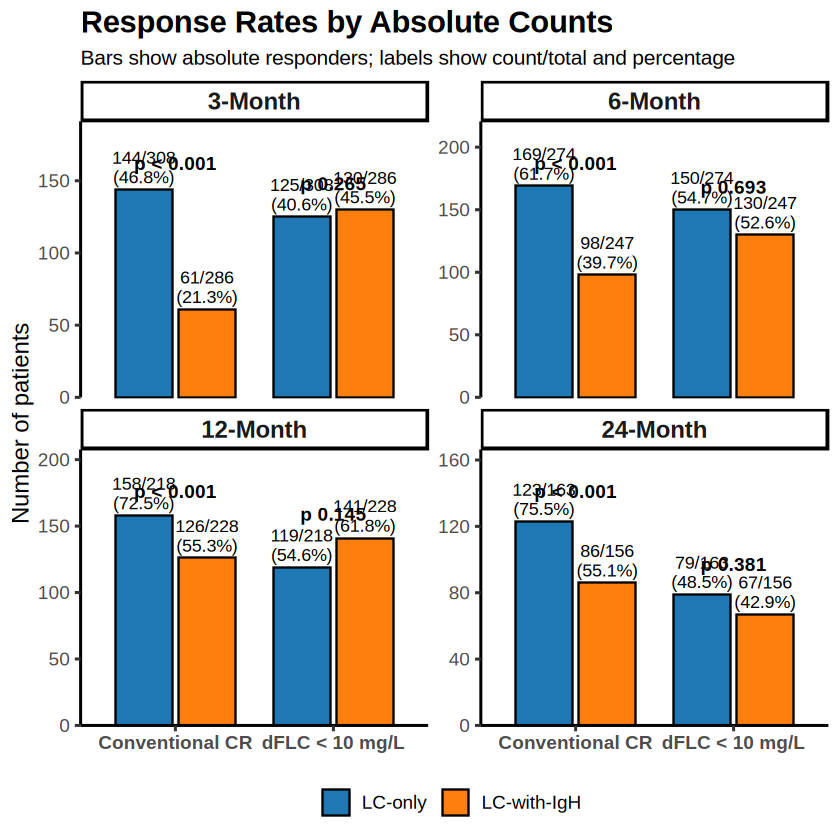

In [1]:
library(tidyverse)

dat <- tribble(
  ~Timepoint, ~Metric,              ~Group,          ~n_total, ~count, ~percent, ~p_value,
  "3-Month",  "Conventional CR",    "LC-only",       308,      144,    46.8,     "< 0.001",
  "3-Month",  "Conventional CR",    "LC-with-IgH",   286,       61,    21.3,     "< 0.001",
  "3-Month",  "dFLC < 10 mg/L",     "LC-only",       308,      125,    40.6,     "0.265",
  "3-Month",  "dFLC < 10 mg/L",     "LC-with-IgH",   286,      130,    45.5,     "0.265",

  "6-Month",  "Conventional CR",    "LC-only",       274,      169,    61.7,     "< 0.001",
  "6-Month",  "Conventional CR",    "LC-with-IgH",   247,       98,    39.7,     "< 0.001",
  "6-Month",  "dFLC < 10 mg/L",     "LC-only",       274,      150,    54.7,     "0.693",
  "6-Month",  "dFLC < 10 mg/L",     "LC-with-IgH",   247,      130,    52.6,     "0.693",

  "12-Month", "Conventional CR",    "LC-only",       218,      158,    72.5,     "< 0.001",
  "12-Month", "Conventional CR",    "LC-with-IgH",   228,      126,    55.3,     "< 0.001",
  "12-Month", "dFLC < 10 mg/L",     "LC-only",       218,      119,    54.6,     "0.145",
  "12-Month", "dFLC < 10 mg/L",     "LC-with-IgH",   228,      141,    61.8,     "0.145",

  "24-Month", "Conventional CR",    "LC-only",       163,      123,    75.5,     "< 0.001",
  "24-Month", "Conventional CR",    "LC-with-IgH",   156,       86,    55.1,     "< 0.001",
  "24-Month", "dFLC < 10 mg/L",     "LC-only",       163,       79,    48.5,     "0.381",
  "24-Month", "dFLC < 10 mg/L",     "LC-with-IgH",   156,       67,    42.9,     "0.381"
)

dat <- dat %>%
  mutate(
    Timepoint = factor(Timepoint, levels = c("3-Month", "6-Month", "12-Month", "24-Month")),
    Metric = factor(Metric, levels = c("Conventional CR", "dFLC < 10 mg/L")),
    Group = factor(Group, levels = c("LC-only", "LC-with-IgH")),
    Group_lab = case_when(
      Group == "LC-only" ~ paste0("LC-only\n(n=", n_total, ")"),
      Group == "LC-with-IgH" ~ paste0("LC-with-IgH\n(n=", n_total, ")")
    ),
    label = paste0(count, "/", n_total, "\n(", percent, "%)")
  )

pdat <- dat %>%
  group_by(Timepoint, Metric) %>%
  summarise(
    ymax = max(count),
    p_value = first(p_value),
    .groups = "drop"
  ) %>%
  mutate(y = ymax + 18)

pd <- position_dodge(width = 0.8)

ggplot(dat, aes(x = Metric, y = count, fill = Group)) +
  geom_col(position = pd, width = 0.72, color = "black") +
  geom_text(
    aes(label = label),
    position = pd,
    vjust = -0.2,
    size = 3.6,
    lineheight = 0.95
  ) +
  geom_text(
    data = pdat,
    aes(x = Metric, y = y, label = paste0("p ", p_value)),
    inherit.aes = FALSE,
    size = 4,
    fontface = "bold"
  ) +
  facet_wrap(~Timepoint, nrow = 2, scales = "free_y") +
  scale_fill_manual(
    values = c(
      "LC-only" = "#1f77b4",
      "LC-with-IgH" = "#ff7f0e"
    ),
    labels = c(
      "LC-only" = "LC-only",
      "LC-with-IgH" = "LC-with-IgH"
    )
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.18))
  ) +
  labs(
    title = "Response Rates by Absolute Counts",
    subtitle = "Bars show absolute responders; labels show count/total and percentage",
    x = NULL,
    y = "Number of patients",
    fill = NULL
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 14),
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 12),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom",
    legend.text = element_text(size = 11)
  )

In [2]:
p <- ggplot(dat, aes(x = Metric, y = count, fill = Group)) +
  geom_col(position = pd, width = 0.72, color = "black") +
  geom_text(
    aes(label = label),
    position = pd,
    vjust = -0.2,
    size = 3.6,
    lineheight = 0.95
  ) +
  geom_text(
    data = pdat,
    aes(x = Metric, y = y, label = paste0("p ", p_value)),
    inherit.aes = FALSE,
    size = 4,
    fontface = "bold"
  ) +
  facet_wrap(~Timepoint, nrow = 2, scales = "free_y") +
  scale_fill_manual(
    values = c(
      "LC-only" = "#1f77b4",
      "LC-with-IgH" = "#ff7f0e"
    ),
    labels = c(
      "LC-only" = "LC-only",
      "LC-with-IgH" = "LC-with-IgH"
    )
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.18))
  ) +
  labs(
    title = "Response Rates by Absolute Counts",
    subtitle = "Bars show absolute responders; labels show count/total and percentage",
    x = NULL,
    y = "Number of patients",
    fill = NULL
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 14),
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 12),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom",
    legend.text = element_text(size = 11)
  )
ggsave(
  filename = "response_barplot.pdf",
  plot = p,
  device = cairo_pdf,   # better text rendering
  width = 8,
  height = 8,
  units = "in"
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Light chain only (λ/κ)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Light chain only (λ/κ)' in 'mbcsToSbcs': dot substituted for <bb>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Light chain only (λ/κ)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Light chain only (λ/κ)' in 'mbcsToSbcs': dot substituted for <ba>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deaths ≤3m' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deaths ≤3m' in 'mbcsToSbcs': dot substitu

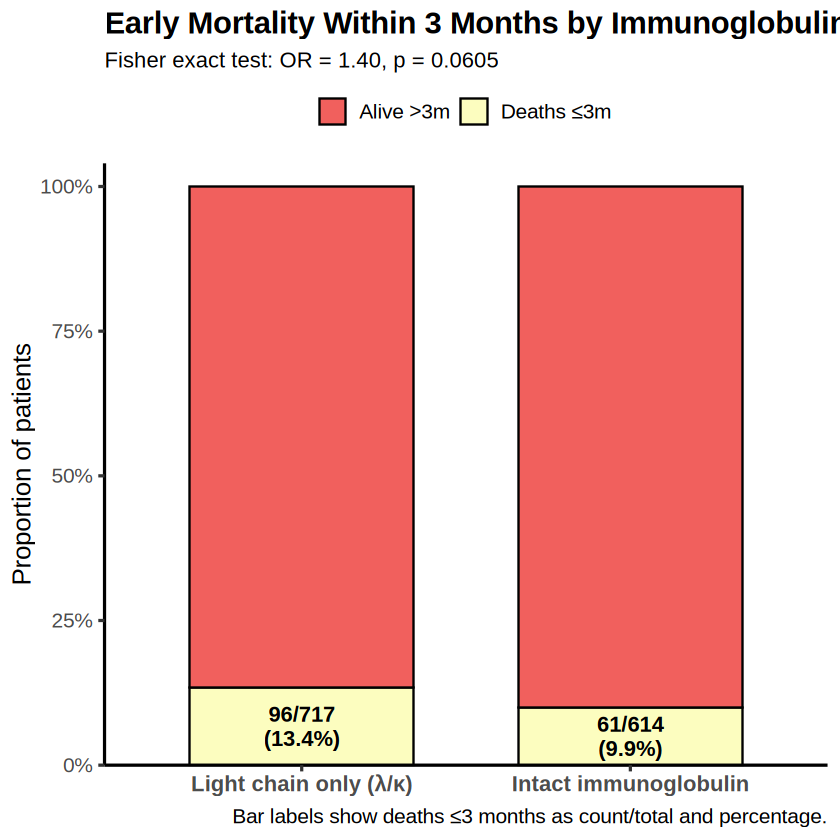

In [14]:
library(tidyverse)
library(viridis)

dat <- tibble(
  Group = c("Light chain only (λ/κ)", "Intact immunoglobulin"),
  N = c(717, 614),
  Death_3m = c(96, 61)
) %>%
  mutate(
    Alive_after_3m = N - Death_3m,
    Death_rate = Death_3m / N
  )

plot_dat <- dat %>%
  select(Group, N, Death_3m, Alive_after_3m) %>%
  pivot_longer(
    cols = c(Death_3m, Alive_after_3m),
    names_to = "Status",
    values_to = "Count"
  ) %>%
  mutate(
    Status = recode(
      Status,
      Death_3m = "Deaths ≤3m",
      Alive_after_3m = "Alive >3m"
    ),
    Group = factor(Group, levels = c("Light chain only (λ/κ)", "Intact immunoglobulin"))
  ) %>%
  group_by(Group) %>%
  mutate(
    Percent = Count / sum(Count),
    ypos = cumsum(Percent) - 0.5 * Percent
  ) %>%
  ungroup()

death_labels <- dat %>%
  mutate(
    Group = factor(Group, levels = c("Light chain only (λ/κ)", "Intact immunoglobulin")),
    label = paste0(Death_3m, "/", N, "\n(", round(100 * Death_rate, 1), "%)")
  )

p <- ggplot(plot_dat, aes(x = Group, y = Percent, fill = Status)) +
  geom_col(width = 0.68, color = "black") +
  geom_text(
    data = death_labels,
    aes(
      x = Group,
      y = Death_3m / N / 2,
      label = label
    ),
    inherit.aes = FALSE,
    size = 4.5,
    fontface = "bold",
    lineheight = 0.95
  ) +
  scale_fill_manual(
    values = c(
      "Deaths ≤3m" = viridis::magma(4)[4],
      "Alive >3m"  = viridis::magma(4)[3]
    )
  ) +
  scale_y_continuous(
    labels = function(x) paste0(round(x * 100), "%"),
    expand = expansion(mult = c(0, 0.04))
  ) +
  labs(
    title = "Early Mortality Within 3 Months by Immunoglobulin Group",
    subtitle = "Fisher exact test: OR = 1.40, p = 0.0605",
    x = NULL,
    y = "Proportion of patients",
    fill = NULL,
    caption = "Bar labels show deaths ≤3 months as count/total and percentage."
  ) +
  theme_classic(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    axis.text.x = element_text(face = "bold", size = 13),
    legend.position = "top"
  )

p

In [16]:
ggsave(
  "fisher_early_death_stacked.pdf",
  plot = p,
  device = cairo_pdf,
  width = 6,
  height = 6,
  units = "in"
)